### An Invitation to Analytic Combinatorics - Lecture 1

This SageMath notebook contains the Sage code presented in Lecture 1 of the MPI Lecture Series presented by Stephen Melczer in June 2026.

### Part 1: Computing with Constants

In [1]:
# An unsolvable (in radicals) quintic
P = QQ['x'](x^5 - 4*x + 1)
P.galois_group().is_solvable()

False

The next 3 cells prove the identity
$$ \frac{\sin\left(\frac{2\pi}{7}\right)}{\sin\left(\frac{3\pi}{7}\right)^2} - \frac{\sin\left(\frac{\pi}{7}\right)}{\sin\left(\frac{2\pi}{7}\right)^2} + \frac{\sin\left(\frac{3\pi}{7}\right)}{\sin\left(\frac{\pi}{7}\right)^2} = 2\sqrt{7}$$
of Ramanujan (Exercise 6.7 in Algorithmes Eﬃcaces en Calcul Formel by Bostan et al., 2017).

In [2]:
# Express LHS in terms of x = exp(I*pi/7) so x^7 = -1
var('x t')
C = pi/7
sbs = [e^(k*I*C)==x^k for k in [-3,-2,-1,1,2,3]]
LHS = sin(2*C)/sin(3*C)^2 - sin(C)/sin(2*C)^2 + sin(3*C)/sin(C)^2
LHSe = LHS.exponentialize().subs(sbs)
show(LHSe)

-1/2*(I*x^2 - I/x^2)/(-1/2*I*x^3 + 1/2*I/x^3)^2 + 1/2*(I*x - I/x)/(-1/2*I*x^2 + 1/2*I/x^2)^2 - 1/2*(I*x^3 - I/x^3)/(-1/2*I*x + 1/2*I/x)^2

In [3]:
# Eliminate x to get equation satisfied by t = LHS
P = QuadraticField(-1)[t][x]((t-LHSe).numerator())
Q = QuadraticField(-1)[t][x](x^7+1)
P.resultant(Q).factor()

(-1274) * (t^2 - 28)^3

In [4]:
# The LHS is > 0 so it equals 2*sqrt(7)
LHS.n()

5.29150262212918

### Part 2: Computing with Sequences

In [5]:
# Computing Fibonacci numbers efficiently
M = Matrix(ZZ,2,2,[1,1,1,0])
 
def bin_pow(n):
  if     n == 1: return M
  elif n%2 == 0: return bin_pow(n/2)^2
  else:          return bin_pow((n-1)/2)^2 * M
  
def fib(n):      return add(bin_pow(n)[1])

timeit('fib(10^6)') # 208,988 digits long!

125 loops, best of 3: 2.79 ms per loop

In [6]:
# Factoring the GF of throwing two dice
A.<z> = ZZ['z']
F = (z+z^2+z^3+z^4+z^5+z^6)^2
F.factor()

z^2 * (z + 1)^2 * (z^2 - z + 1)^2 * (z^2 + z + 1)^2

In [7]:
# One grouping of the factors giving a polynomial with positive integer coefficients summing to 6
P = z*(z+1)*(1+z+z^2)
P

z^4 + 2*z^3 + 2*z^2 + z

In [8]:
# The other factor also has positive integer coefficients summing to 6
F / P

z^8 + z^6 + z^5 + z^4 + z^3 + z

In [9]:
# Proving the GF T(z) of 5-ary trees is not solvable in radicals, since T(1/100) is not
# This requires knowing that 1/100 is in the radius of convergence of T(z), which we prove next lecture
A.<y> = QQ['y']
F = y^5 - 100*y + 100
F.galois_group().is_solvable()

False

In [10]:
# Introduce lazy power series
S.<z> = LazyPowerSeriesRing(QQ)
  
# Define the class of positive integers
P = z/(1-z)
  
# Define the class of integer compositions
C = 1/(1-P)
C

1 + z + 2*z^2 + 4*z^3 + 8*z^4 + 16*z^5 + 32*z^6 + O(z^7)

In [11]:
# Get the number of compositions of size 100
C[100]

633825300114114700748351602688

In [12]:
# Define the class of binary trees
B = S.undefined()
B.define(1+z*B^2)
B

1 + z + 2*z^2 + 5*z^3 + 14*z^4 + 42*z^5 + 132*z^6 + O(z^7)

In [13]:
# Get the number of trees of size 100
B[100]

896519947090131496687170070074100632420837521538745909320

In [14]:
# Can search and pull info directly from OEIS
# NOTE: Commented out as a default Sage installation often has SSL certificate errors
# oeis(B[:30])

In [15]:
# NOTE: Jupyter can have SSL errors with a default Sage installation
# If you get "OSError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED]..."
# then uncomment and run the following code (or run the oeis command in a terminal)
#import ssl
#import urllib.request
#import certifi
#secure_context = ssl.create_default_context(cafile=certifi.where())
#secure_handler = urllib.request.HTTPSHandler(context=secure_context)
#opener = urllib.request.build_opener(secure_handler)
#urllib.request.install_opener(opener)

### Part 3: Rational Generating Functions

In [16]:
# Introduce C-Finite Sequence
C.<z> = CFiniteSequences(QQ)
  
# Define the sequence satisfying the recurrence
# a_n = a_{n-1} + a_{n-2} with a_0 = a_1 = 1
fib = C.from_recurrence([1,1],[1,1]) 
fib

C-finite sequence, generated by -1/(z^2 + z - 1)

In [17]:
# We can compute coefficients
# This is actually not as fast as using the PowerSeriesRing
fib[100]

573147844013817084101

In [18]:
# Print closed form 
show(fib.closed_form())

1/2*(1/2*sqrt(5) + 1/2)^n*(sqrt(1/5) + 1) - 1/2*(-1/2*sqrt(5) + 1/2)^n*(sqrt(1/5) - 1)

In [19]:
# One can also define a sequence from its GF
expr = C(1/(1-z-z^2-z^5)).closed_form()
expr

0.6166275139556477?*1.704902776041646?^n + (0.05380265792086830? - 0.09461946035179473?*I)*(0.4285384205655347? + 0.710200650526218?*I)^n + (0.05380265792086830? + 0.09461946035179473?*I)*(0.4285384205655347? - 0.710200650526218?*I)^n + (0.1378835851013079? + 0.01667956381901742?*I)*(-0.780989808586358? + 0.4924957186473319?*I)^n + (0.1378835851013079? - 0.01667956381901742?*I)*(-0.780989808586358? - 0.4924957186473319?*I)^n

In [20]:
# It is possible to extract each constant
base = expr.operands()[0].operands()[0].operands()[0]
base

1.704902776041646?

In [21]:
# Constants are stored exactly using Sage's AlgebraicField
# We can compute their annihilating polynomials
base.minpoly()

x^5 - x^4 - x^3 - 1

In [22]:
# And numerical approximations to any accuracy
base.n(digits=50)

1.7049027760416460700699078453581855619122727078940

In [23]:
# Define the rational GF for Conway's look-and-say digit sequence
G = -12*z^78+18*z^77-18*z^76+18*z^75-18*z^74+20*z^73+22*z^72-31*z^71-15*z^70+4*z^69+4*z^68+19*z^67-62*z^66+50*z^65+21*z^64+11*z^63-41*z^62-54*z^61+56*z^60+44*z^59-15*z^58+27*z^57+15*z^56-45*z^55+8*z^54-89*z^53+64*z^52+66*z^51+25*z^50-38*z^49-126*z^48+39*z^47+32*z^46+33*z^45+65*z^44-107*z^43-14*z^42-16*z^41+13*z^40+79*z^39-7*z^38-42*z^37-12*z^36-8*z^35+26*z^34+9*z^33-35*z^32+23*z^31+20*z^30+30*z^29-34*z^28-58*z^27+z^26+20*z^25+36*z^24+6*z^23-13*z^22-8*z^21-6*z^20-3*z^19+z^18+4*z^17+z^16+4*z^15+5*z^14+z^13-8*z^12-6*z^11+6*z^9+4*z^8-z^7-z^5-z^4-z^3-z^2+z+1
H = 6*z^72-9*z^71+9*z^70-18*z^69+16*z^68-11*z^67+14*z^66-8*z^65+z^64-5*z^63+7*z^62+2*z^61+8*z^60-14*z^59-5*z^58-5*z^57+19*z^56+3*z^55-6*z^54-7*z^53-6*z^52+16*z^51-7*z^50+8*z^49-22*z^48+17*z^47-12*z^46+7*z^45+5*z^44+7*z^43-8*z^42+4*z^41-7*z^40-9*z^39+13*z^38-4*z^37-6*z^36+14*z^35-14*z^34+19*z^33-7*z^32-13*z^31+2*z^30-4*z^29+18*z^28-z^26-4*z^25-12*z^24+8*z^23-5*z^22+8*z^20+z^19+7*z^18-8*z^17-5*z^16-2*z^15+3*z^14+3*z^13-2*z^8-z^7+3*z^5+z^4-z^3-z^2-z+1

F = G/H
digitseq = C(F)

In [24]:
digitseq[100]

666450031706

In [25]:
digitseq.recurrence_repr()

'homogeneous linear recurrence with constant coefficients of degree 72: a(n+72) = a(n+71) + a(n+70) + a(n+69) - a(n+68) - 3*a(n+67) + a(n+65) + 2*a(n+64) - 3*a(n+59) - 3*a(n+58) + 2*a(n+57) + 5*a(n+56) + 8*a(n+55) - 7*a(n+54) - a(n+53) - 8*a(n+52) + 5*a(n+50) - 8*a(n+49) + 12*a(n+48) + 4*a(n+47) + a(n+46) - 18*a(n+44) + 4*a(n+43) - 2*a(n+42) + 13*a(n+41) + 7*a(n+40) - 19*a(n+39) + 14*a(n+38) - 14*a(n+37) + 6*a(n+36) + 4*a(n+35) - 13*a(n+34) + 9*a(n+33) + 7*a(n+32) - 4*a(n+31) + 8*a(n+30) - 7*a(n+29) - 5*a(n+28) - 7*a(n+27) + 12*a(n+26) - 17*a(n+25) + 22*a(n+24) - 8*a(n+23) + 7*a(n+22) - 16*a(n+21) + 6*a(n+20) + 7*a(n+19) + 6*a(n+18) - 3*a(n+17) - 19*a(n+16) + 5*a(n+15) + 5*a(n+14) + 14*a(n+13) - 8*a(n+12) - 2*a(n+11) - 7*a(n+10) + 5*a(n+9) - a(n+8) + 8*a(n+7) - 14*a(n+6) + 11*a(n+5) - 16*a(n+4) + 18*a(n+3) - 9*a(n+2) + 9*a(n+1) - 6*a(n), starting a(0...) = [1, 2, 2, 4, 6, 6, 8, 10, 14, 20, 26, 34, 46, 62, 78, 102, 134, 176, 226, 302, 408, 528, 678, 904, 1182, 1540, 2012, 2606, 3410, 44

In [26]:
# Takes 10+ minutes
# Constants are degree 71 algebraic numbers!
# asm = digitseq.closed_form()
# asm

In [27]:
# Find all singularities of minimal modulus for the look-and-say digit GF
rho = min([abs(r[0]) for r in H.roots(QQbar)])
[r[0] for r in H.roots(QQbar) if abs(r[0]) == rho]

[0.7671198507019154?]

In [28]:
# Dominant asymptotics for the look-and-say digit sequence
var('n')
(-G/z/H.derivative(z)).subs(z=rho) * (1/rho)^n

2.042160076857881?*1.303577269034297?^n

In [29]:
# Define the sequence satisfying 
# a(n+4) = -2*a(n+3) + 5*a(n+2) - 4*a(n+1) + a(n)
# with a(0) = a(1) = a(2) = a(3) = 1 
a = C.from_recurrence([1,-4,5,-2],[1,1,1,1])
a[:11]

[1, 1, 1, 1, 0, 2, -7, 25, -93, 341, -1254]

In [30]:
# Bernoulli's polynomial has a unique root of minimal modulus
A.<x> = QQ[x]
H     = -1-2*x+5*x^2-4*x^3+x^4
rts   = H.roots(QQbar,multiplicities=False)
[abs(k) for k in rts]

[0.2720196495140690?,
 2.272019649514069?,
 1.272019649514069?,
 1.272019649514069?]

In [31]:
# The ratio of terms approximates this root
(341/(-1254)).n()

-0.271929824561404

In [32]:
rho = rts[0]
rho

-0.2720196495140690?

In [33]:
# We get exponential convergence to the correct value
for k in range(5,20):
    print((a[k]/a[k+1]).n(digits=10))
print(rho)

-0.2857142857
-0.2800000000
-0.2688172043
-0.2727272727
-0.2719298246
-0.2720173536
-0.2720245471
-0.2720181056
-0.2720199449
-0.2720196208
-0.2720196457
-0.2720196521
-0.2720196488
-0.2720196496
-0.2720196495
-0.2720196495140690?


In [34]:
# Asymptotics for the number of ways to make change for n euro cents
var('n t')
H = (1-t^200)*(1-t^100)*(1-t^50)*(1-t^20)*(1-t^10)*(1-t^5)*(1-t^2)*(1-t)
m = 8
asm = m/(-1)^m/H.derivative(t,8).subs(t=1) * n^(m-1)
asm

1/10080000000000*n^7

In [35]:
# Verify denominator in closed form
2*5*10*20*50*100*200 * factorial(7)

10080000000000

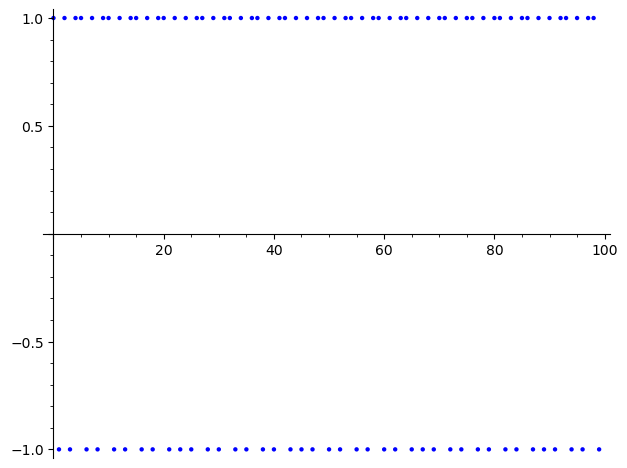

In [36]:
# How Bad Can it Get?
A.<z> = QQ[[z]]
ser = 1/(8 + 7*z - 9*z^2 - 17*z^3 + O(z^(10001)))
u = ser.coefficients()
show(point([[k,sgn(u[k])] for k in range(100)]))

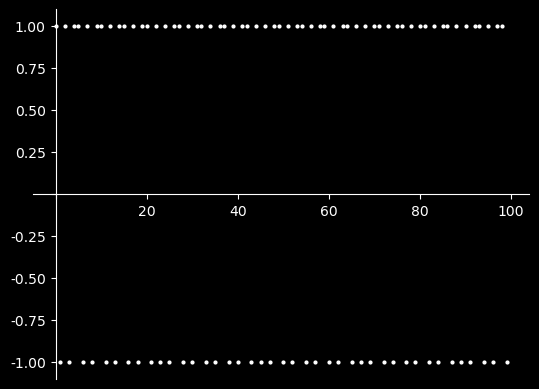

In [37]:
# Generate plot with black background for slides
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use('dark_background')
N = 100

k_values = list(range(N))
u_values = [sgn(u[k]) for k in k_values]

fig, ax = plt.subplots(facecolor='black')
ax.set_facecolor('black')

ax.plot(k_values, u_values, 'o', color='white', markersize=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.ticklabel_format(style='plain', axis='y')

def hide_zero_x(val, pos):
    if val == 0:
        return ''
    return f'{int(val)}'

def hide_zero_y(val, pos):
    if val == 0:
        return ''
    return f'{val:.2f}'

ax.xaxis.set_major_formatter(FuncFormatter(hide_zero_x))
ax.yaxis.set_major_formatter(FuncFormatter(hide_zero_y))

plt.show()

In [38]:
# Reset back to default plotting for now
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('default')
mpl.rcParams.update(mpl.rcParamsDefault)

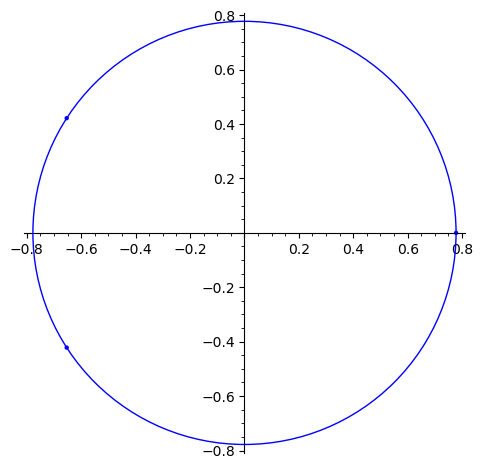

In [39]:
# Plot roots of denominator and circle of minimal modulus
# (ignore styling to make code fit on slide)
A.<z> = QQ[z]
H = 8 + 7*z - 9*z^2 - 17*z^3
rts = H.roots(QQbar,multiplicities=False)
rho = rts[0]

from sage.plot.circle import circle
c_plot = circle((0, 0), abs(rho))
p_plot = list_plot(rts)
show(c_plot + p_plot)

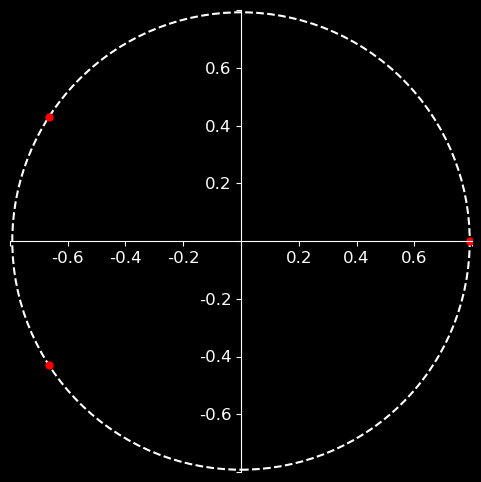

In [40]:
# Generate plot with black and white background for slides
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator
from matplotlib.patches import Circle
from matplotlib.ticker import LinearLocator

plt.style.use('dark_background')

w = abs(rho)

fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
ax.set_facecolor('black')

circle = Circle((0, 0), radius=w, fill=False, edgecolor='white', linestyle='dashed', linewidth=1.5)
ax.add_patch(circle)

ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

def hide_zero_x(val, pos): return '' if val == 0 or abs(val)>0.7 else f'{val:.1f}'
def hide_zero_y(val, pos): return '' if val == 0 or abs(val)>0.7 else f'{val:.1f}'
ax.xaxis.set_major_formatter(FuncFormatter(hide_zero_x))
ax.yaxis.set_major_formatter(FuncFormatter(hide_zero_y))

ax.plot([k.real() for k in rts], [k.imag() for k in rts], 'o', markerfacecolor='red', markeredgecolor='red', markersize=5)
ax.set_xlim(-1.01*w, 1.01*w)
ax.set_ylim(-1.01*w, 1.01*w)

ax.xaxis.set_major_locator(LinearLocator(numticks=9))
ax.yaxis.set_major_locator(LinearLocator(numticks=9))
ax.tick_params(axis='both', labelsize=12)

plt.show()

In [41]:
# Define function to generate plots zoomed in on lower complex root
def close_plot(delta, digits):
    plt.style.use('dark_background')
    w = abs(rho)
    
    fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
    ax.set_facecolor('black')
    
    circle = Circle((0, 0), radius=w, fill=False, edgecolor='white', linestyle='dashed', linewidth=3)
    ax.add_patch(circle)
    ax.set_aspect('equal')
    
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    
    ax.xaxis.tick_top()
    ax.yaxis.tick_right()
    
    def hide_zero_x(val, pos): return '' if val == 0 else f'{val:.{digits}f}'
    def hide_zero_y(val, pos): return '' if val == 0 else f'{val:.{digits}f}'
    ax.xaxis.set_major_formatter(FuncFormatter(hide_zero_x))
    ax.yaxis.set_major_formatter(FuncFormatter(hide_zero_y))
    
    ax.xaxis.set_minor_locator(MultipleLocator(0.01))
    
    ax.plot([k.real() for k in rts], [k.imag() for k in rts], 'o', markerfacecolor='red', markeredgecolor='red', markersize=10)
    ax.set_xlim(pr-delta, pr+delta)
    ax.set_ylim(p_im-delta,p_im+delta)
    
    ax.xaxis.set_major_locator(LinearLocator(numticks=5))
    ax.yaxis.set_major_locator(LinearLocator(numticks=5))
    ax.tick_params(axis='both', labelsize=13)

    plt.show()

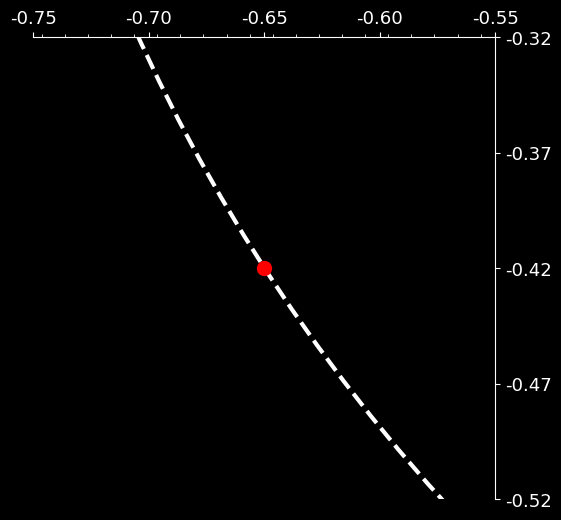

In [42]:
pr = rts[1].real().n()
p_im = rts[1].imag().n()
close_plot(0.1, 2)

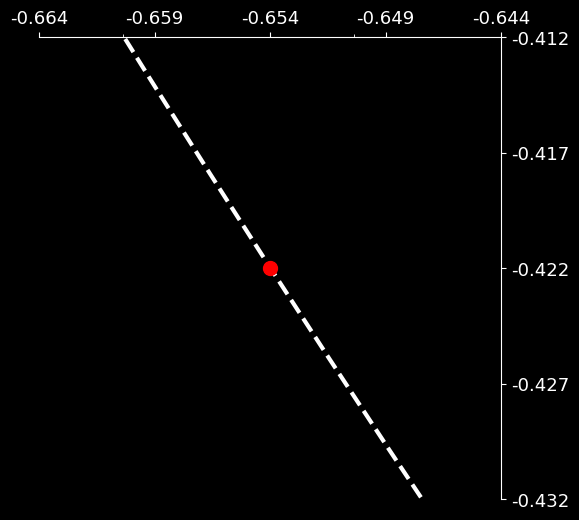

In [43]:
close_plot(0.01, 3)

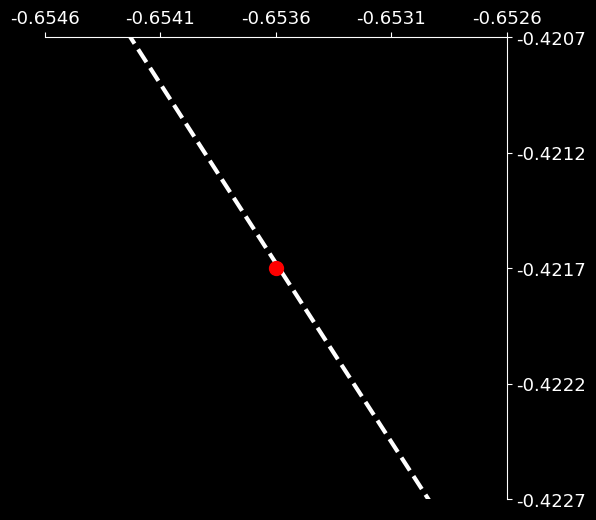

In [44]:
close_plot(0.001, 4)

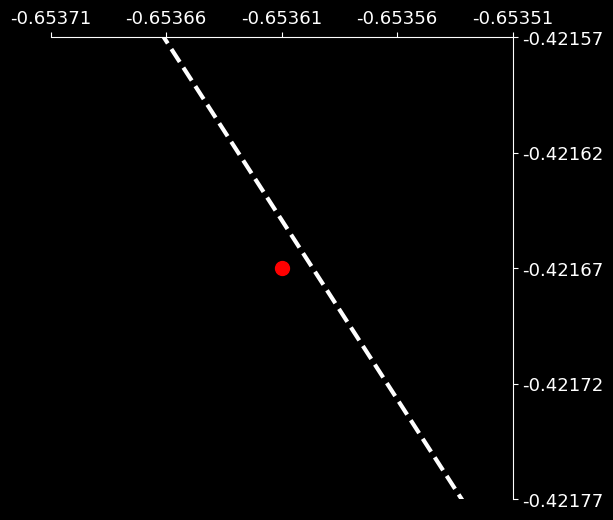

In [45]:
close_plot(0.0001, 5)